In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("traffic.csv")

df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [4]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

In [5]:
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Day"] = df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.dayofweek

In [6]:
df = df.drop(["ID","DateTime"], axis=1)

df.head()

,Junction,Vehicles,Year,Month,Day,Hour,DayOfWeek
0,1,15,2015,11,1,0,6
1,1,13,2015,11,1,1,6
2,1,10,2015,11,1,2,6
3,1,7,2015,11,1,3,6
4,1,9,2015,11,1,4,6


In [7]:
df.describe()

,Junction,Vehicles,Year,Month,Day,Hour,DayOfWeek
count,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000,48120.000000
mean,2.180549,22.791334,2016.269825,5.884289,15.700748,11.500000,2.996010
std,0.966955,20.750063,0.616093,3.569872,8.784073,6.922258,2.000017
min,1.000000,1.000000,2015.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,9.000000,2016.000000,3.000000,8.000000,5.750000,1.000000
50%,2.000000,15.000000,2016.000000,5.000000,16.000000,11.500000,3.000000
75%,3.000000,29.000000,2017.000000,9.000000,23.000000,17.250000,5.000000
max,4.000000,180.000000,2017.000000,12.000000,31.000000,23.000000,6.000000


In [8]:
df.corr()

,Junction,Vehicles,Year,Month,Day,Hour,DayOfWeek
Junction,1.000000e+00,-0.613787,2.212977e-01,-1.242771e-01,-2.094621e-03,-2.132575e-15,-6.590970e-04
Vehicles,-6.137872e-01,1.000000,2.212531e-01,-2.272345e-02,2.789498e-02,2.199377e-01,-1.260265e-01
Year,2.212977e-01,0.221253,1.000000e+00,-6.234957e-01,-7.474779e-03,7.732006e-16,1.278526e-03
Month,-1.242771e-01,-0.022723,-6.234957e-01,1.000000e+00,9.154760e-03,4.953278e-16,-3.208219e-03
Day,-2.094621e-03,0.027895,-7.474779e-03,9.154760e-03,1.000000e+00,-9.917806e-18,-8.628855e-04
Hour,-2.132575e-15,0.219938,7.732006e-16,4.953278e-16,-9.917806e-18,1.000000e+00,6.442124e-18
DayOfWeek,-6.590970e-04,-0.126027,1.278526e-03,-3.208219e-03,-8.628855e-04,6.442124e-18,1.000000e+00


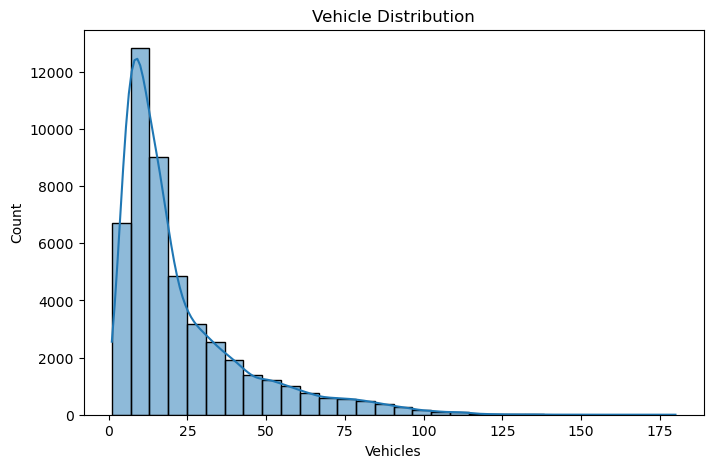

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["Vehicles"], bins=30, kde=True)
plt.title("Vehicle Distribution")
plt.show()

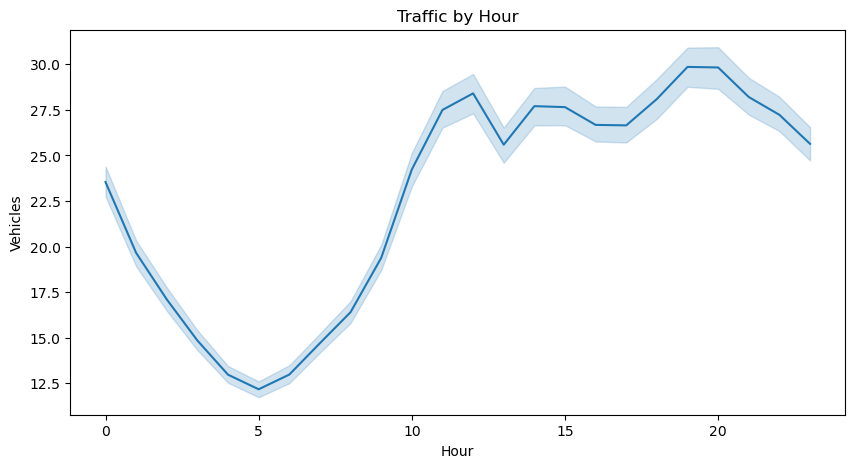

In [10]:
plt.figure(figsize=(10,5))
sns.lineplot(x="Hour", y="Vehicles", data=df)
plt.title("Traffic by Hour")
plt.show()

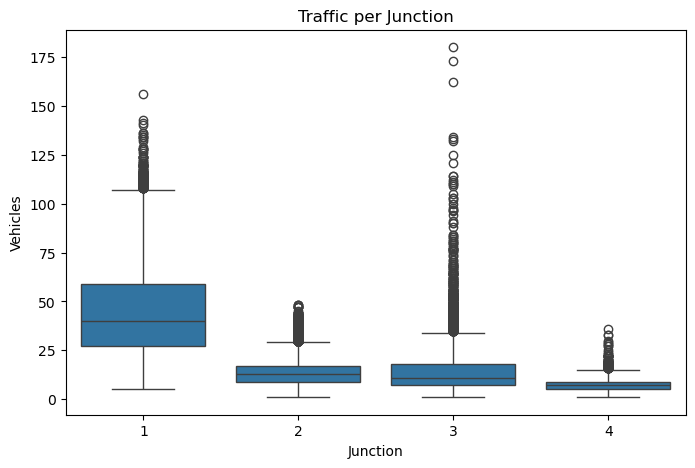

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Junction", y="Vehicles", data=df)
plt.title("Traffic per Junction")
plt.show()

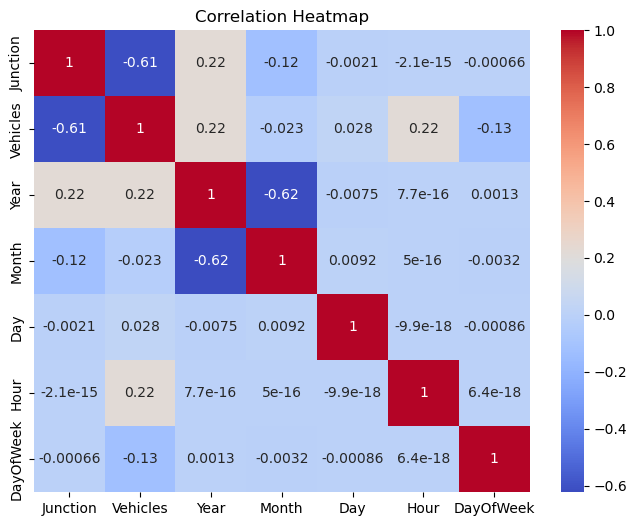

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
X = df.drop("Vehicles", axis=1)
y = df["Vehicles"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(38496, 6)
(9624, 6)


In [15]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression R2 Score:", r2_score(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression R2 Score: 0.5997395466491218
RMSE: 12.772033686571424


In [16]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree R2 Score:", r2_score(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))

Decision Tree R2 Score: 0.9432781841624153
RMSE: 4.80799244539194


In [17]:
rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest R2 Score: 0.9686561021987534
RMSE: 3.5740877844943624


In [18]:
gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting R2 Score:", r2_score(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))

Gradient Boosting R2 Score: 0.9017017892779206
RMSE: 6.329385097690485


In [19]:
models = ["Linear Regression","Decision Tree","Random Forest","Gradient Boosting"]

scores = [
r2_score(y_test, lr_pred),
r2_score(y_test, dt_pred),
r2_score(y_test, rf_pred),
r2_score(y_test, gb_pred)
]

results = pd.DataFrame({
"Model": models,
"Accuracy": scores
})

results

,Model,Accuracy
0,Linear Regression,0.599740
1,Decision Tree,0.943278
2,Random Forest,0.968656
3,Gradient Boosting,0.901702


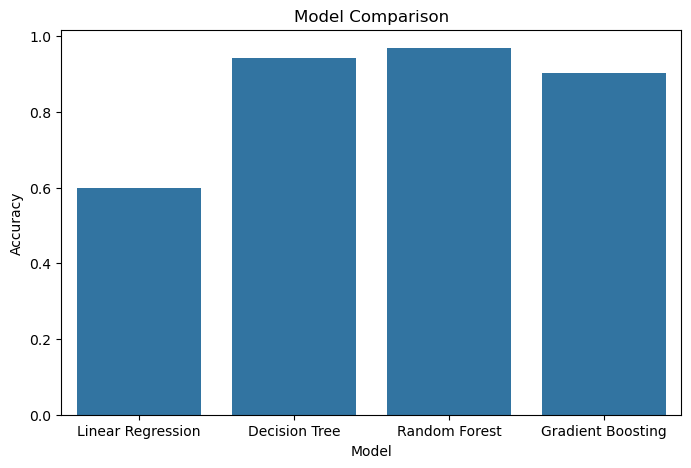

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Comparison")
plt.show()

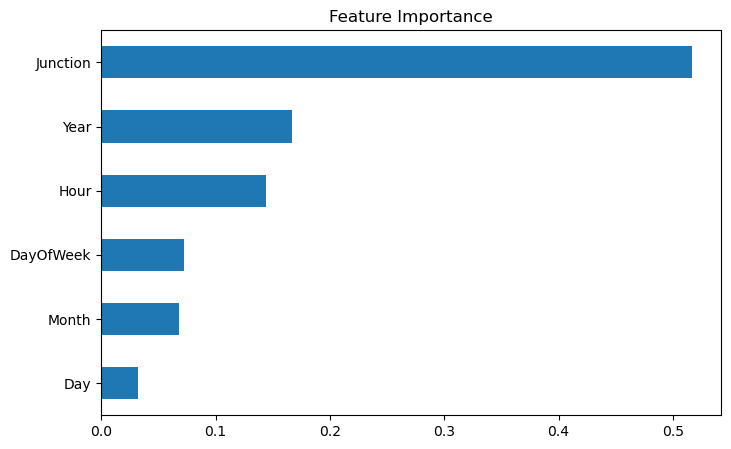

In [21]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Feature Importance")
plt.show()

In [22]:
sample = X_test.iloc[0:1]

prediction = rf.predict(sample)

print("Predicted Traffic Vehicles:", prediction)

Predicted Traffic Vehicles: [10.16]
